In [1]:
import sys 
import os 
from pathlib import Path
import pandas as pd

REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "code"))

import connectivity_based_clustering
import matplotlib.pyplot as plt
import pickle


In [11]:
TPN1_candi = pickle.load(open(REPO_ROOT/'data/sweet_neuron_list/putative_TPN1_v783.pkl','rb'))

In [39]:
mat_g = connectivity_based_clustering.make_adjacency_matrix_GRN_to_2ndtype(TPN1_candi)
mat_g.to_parquet('connection_matrix_candidate_to_2nd.parquet')
mat_g = pd.read_parquet('connection_matrix_candidate_to_2nd.parquet')
Z = connectivity_based_clustering.cluster_GRNs(mat_g)
colors = ['#00ff00', '#5f5aa6', '#3172b9', '#ff7f00', '#7fbf7f', '#581d87','#d2ba48']

Calc. similarity:   0%|          | 0/196 [00:00<?, ?it/s]

Calc. similarity:   0%|          | 0/196 [00:00<?, ?it/s]

/volume_4/research/seongbong/flywire/yu_desilva_geosmin_release/code/connectivity_based_clustering.py:124: RuntimeWarning: divide by zero encountered in log10
  mat_data = np.log10(mat_g_sorted[:, np.argsort(np.sum(mat_g_arr,axis=0))[::-1][:50]])


(0.0, 1.0, 0.0, 1.0)

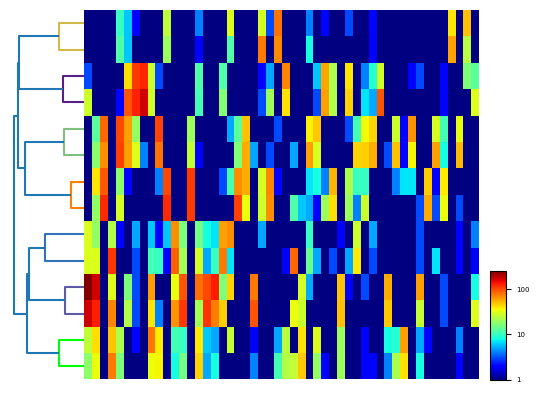

In [42]:
fig,ax= plt.subplots(1,1)
dn = connectivity_based_clustering.draw_dendrogram_with_adjmat(fig,mat_g,TPN1_candi,colors=colors,threshold=.75)
ax.set_xticks([])
ax.set_yticks([])
ax.axis('off')

In [46]:
cells = np.array(dn['ivl'])
colors = np.array(dn['leaves_color_list'])
type_name = [f"T{list(dict.fromkeys(colors)).index(c)+1}" for c in colors]
cluster_info = pd.DataFrame(columns=['flyid','type'])
cluster_info['flyid'] = cells
cluster_info['type'] = type_name
cluster_info['color'] = colors
cluster_info.to_parquet(REPO_ROOT /'data/TPN1_cluster_info_v783.parquet')